# RPG Graph Analysis

This notebook combines the static graph-structure analysis (A) and the dynamic query-conditioned analysis (B). Static cells inspect the item graph itself; dynamic cells read decoding traces if they are available. Item `0` is padding and self-edges are excluded from the static metrics.


In [1]:
from pathlib import Path
import json
import os
import tempfile

os.environ.setdefault('MPLCONFIGDIR', str(Path(tempfile.gettempdir()) / 'rpg-matplotlib'))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == 'notebooks':
    REPO_ROOT = REPO_ROOT.parent

GRAPH_ROOT = REPO_ROOT / 'artifacts' / 'rpg' / 'graph_analysis' / 'sports'
sessions = sorted(p for p in GRAPH_ROOT.iterdir() if (p / 'static' / 'static_summary.csv').is_file())
if not sessions:
    raise FileNotFoundError(f'No completed static graph-analysis sessions found under {GRAPH_ROOT}')
SESSION = sessions[-1]
manifest = json.loads((SESSION / 'manifest.json').read_text())
graph_metadata = json.loads(Path(manifest['graph_metadata']).read_text())
n_digit = int(graph_metadata['n_digit'])
STATIC = SESSION / 'static'
DYNAMIC = SESSION / 'dynamic'

print(SESSION)
print(f"Semantic-ID digits: {n_digit}")
manifest

/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755
Semantic-ID digits: 16


{'adjacency': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/graphs/adjacency_top100.pt',
 'dynamic_outputs': {'first_hit_csv': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/summaries/dynamic_first_hit_summary.csv',
  'per_example_parquet': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/per_example.parquet',
  'reachability_csv': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/summaries/dynamic_reachability_summary.csv',
  'redundancy_csv': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/summaries/dynamic_redundancy_summary.csv',
  'sample_traces_jsonl': '/gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic/traces/sample_traces.jsonl',
  'saturation_csv': '/gpfs/home6/scur1202/RPG/artifacts/rpg/

Load the CSV files produced by the static analysis job. `summary` is the main table; the other files are used for histograms and per-item plots.


In [2]:
summary = pd.read_csv(STATIC / 'static_summary.csv')
similarity_hist = pd.read_csv(STATIC / 'edge_similarity_histogram.csv')
hamming_hist = pd.read_csv(STATIC / 'hamming_histogram.csv')
indegree_hist = pd.read_csv(STATIC / 'indegree_histogram.csv')
popularity_buckets = pd.read_csv(STATIC / 'popularity_buckets.csv')
item_metrics = pd.read_csv(STATIC / 'item_metrics_by_k.csv')

summary

,k,n_nodes,n_edges,edge_similarity_mean,edge_similarity_median,edge_similarity_p10,edge_similarity_p90,random_similarity_mean,random_similarity_median,random_similarity_p10,...,spearman_train_frequency_indegree,spearman_pvalue,pearson_log1p_train_frequency_log1p_indegree,pearson_pvalue,top_1pct_hub_count,top_1pct_hub_train_frequency_mean,top_1pct_hub_train_frequency_median,top_1pct_hub_training_interaction_share,all_items_train_frequency_mean,all_items_train_frequency_median
0,10,18357,165213,0.637190,0.604872,0.575371,0.746529,0.501210,0.499814,0.485925,...,0.140679,8.897142e-82,0.142305,1.183173e-83,184,16.157609,7.5,0.013205,12.264586,7.0
1,20,18357,348783,0.612052,0.586518,0.568861,0.686294,0.501204,0.499810,0.485915,...,0.146625,9.526133e-89,0.150757,9.096565e-94,184,19.114130,8.0,0.015621,12.264586,7.0
2,30,18357,532353,0.599198,0.577130,0.564451,0.656955,0.501220,0.499822,0.485925,...,0.142444,8.168400e-84,0.151204,2.550573e-94,184,19.456522,9.0,0.015901,12.264586,7.0
3,50,18357,899493,0.585043,0.569397,0.557759,0.625821,0.501215,0.499816,0.485915,...,0.134131,1.906068e-74,0.143015,1.765462e-84,184,19.744565,9.0,0.016137,12.264586,7.0
4,100,18357,1817343,0.569229,0.558790,0.549423,0.593001,0.501213,0.499824,0.485909,...,0.136399,6.054224e-77,0.147655,5.514812e-90,184,25.570652,9.0,0.020898,12.264586,7.0


## Edge Similarity and Hamming Distance


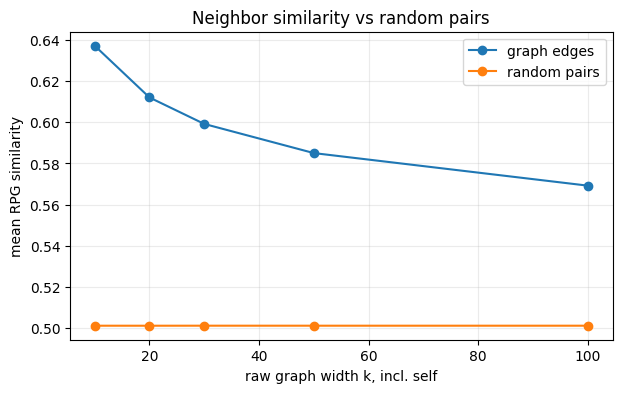

,k,hamming_mean,random_hamming_mean,matching_digits_mean,random_matching_digits_mean
0,10,11.889107,15.928291,4.110893,0.071709
1,20,12.698675,15.928341,3.301325,0.071659
2,30,13.100076,15.928237,2.899924,0.071763
3,50,13.552326,15.928057,2.447674,0.071943
4,100,14.133754,15.928165,1.866246,0.071835


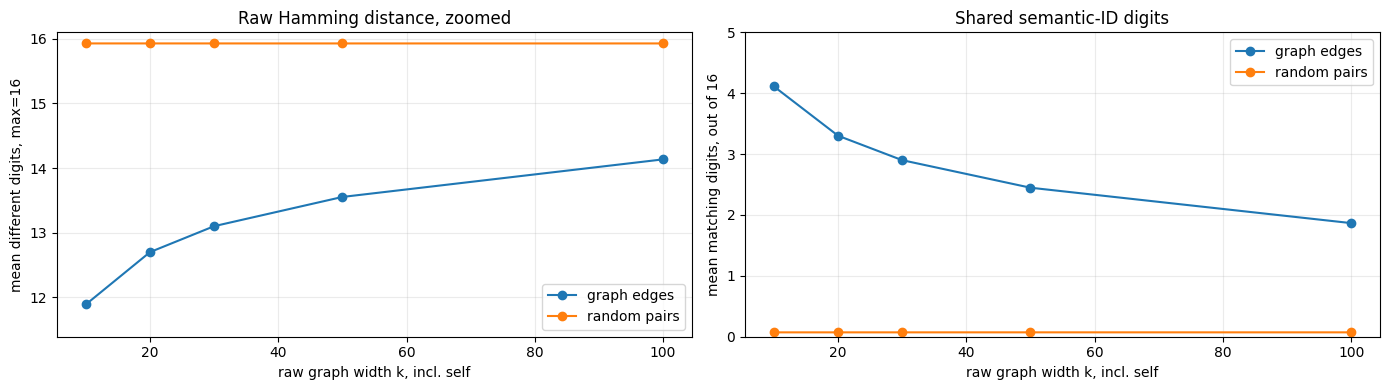

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(summary['k'], summary['edge_similarity_mean'], marker='o', label='graph edges')
ax.plot(summary['k'], summary['random_similarity_mean'], marker='o', label='random pairs')
ax.set_xlabel('raw graph width k, incl. self')
ax.set_ylabel('mean RPG similarity')
ax.set_title('Neighbor similarity vs random pairs')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

a2 = summary.assign(
    matching_digits_mean=n_digit - summary['hamming_mean'],
    random_matching_digits_mean=n_digit - summary['random_hamming_mean'],
)

display(a2[[
    'k',
    'hamming_mean',
    'random_hamming_mean',
    'matching_digits_mean',
    'random_matching_digits_mean',
]])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(summary['k'], summary['hamming_mean'], marker='o', label='graph edges')
axes[0].plot(summary['k'], summary['random_hamming_mean'], marker='o', label='random pairs')
axes[0].set_xlabel('raw graph width k, incl. self')
axes[0].set_ylabel(f'mean different digits, max={n_digit}')
axes[0].set_title('Raw Hamming distance, zoomed')
axes[0].set_ylim(max(0, summary['hamming_mean'].min() - 0.5), n_digit + 0.1)
axes[0].legend()

axes[1].plot(a2['k'], a2['matching_digits_mean'], marker='o', label='graph edges')
axes[1].plot(a2['k'], a2['random_matching_digits_mean'], marker='o', label='random pairs')
axes[1].set_xlabel('raw graph width k, incl. self')
axes[1].set_ylabel(f'mean matching digits, out of {n_digit}')
axes[1].set_title('Shared semantic-ID digits')
axes[1].set_ylim(0, max(5, a2['matching_digits_mean'].max() + 0.5))
axes[1].legend()

for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

- `RPG similarity` is the embedding similarity used to construct the graph. If graph edges are above random pairs, the graph is not arbitrary.
- `Hamming distance` counts how many semantic-ID digits differ. With 16 digits, distance `16` means no digit matches.
- `matching_digits = 16 - hamming` is easier to read: `4` means the two items share about 4 semantic-ID digits.
- Main takeaway: graph neighbors share much more ID structure than random item pairs, but they are still not almost-identical IDs.


## Static Structure

This is the main structural part of the analysis: reciprocity, connected components, and local clustering.


The plots below ask three different questions: are edges symmetric, is the graph already connected, and are neighborhoods locally redundant?


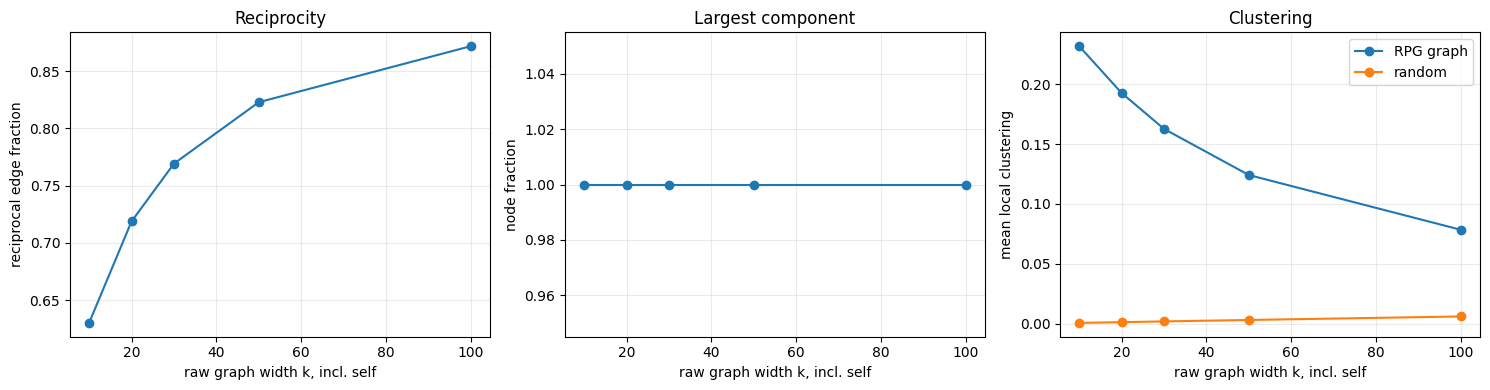

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(summary['k'], summary['reciprocity'], marker='o')
axes[0].set_title('Reciprocity')
axes[0].set_xlabel('raw graph width k, incl. self')
axes[0].set_ylabel('reciprocal edge fraction')

axes[1].plot(summary['k'], summary['largest_component_fraction'], marker='o')
axes[1].set_title('Largest component')
axes[1].set_xlabel('raw graph width k, incl. self')
axes[1].set_ylabel('node fraction')

axes[2].plot(summary['k'], summary['clustering_mean'], marker='o', label='RPG graph')
axes[2].plot(summary['k'], summary['random_clustering_mean'], marker='o', label='random')
axes[2].set_title('Clustering')
axes[2].set_xlabel('raw graph width k, incl. self')
axes[2].set_ylabel('mean local clustering')
axes[2].legend()

for axis in axes:
    axis.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [5]:
static_structure_table = (
    summary[[
        'k',
        'n_components',
        'largest_component_fraction',
        'clustering_mean',
        'random_clustering_mean',
        'clustering_lift_over_random',
    ]]
    .rename(columns={
        'k': 'raw_graph_width_k_incl_self',
        'largest_component_fraction': 'largest_component_fraction',
        'clustering_mean': 'rpg_clustering',
        'random_clustering_mean': 'random_clustering',
        'clustering_lift_over_random': 'clustering_lift',
    })
    .round({
        'largest_component_fraction': 4,
        'rpg_clustering': 6,
        'random_clustering': 6,
        'clustering_lift': 2,
    })
)

static_structure_table


,raw_graph_width_k_incl_self,n_components,largest_component_fraction,rpg_clustering,random_clustering,clustering_lift
0,10,1,1.0,0.231703,0.000714,324.35
1,20,1,1.0,0.192612,0.001315,146.44
2,30,1,1.0,0.162657,0.001960,82.98
3,50,1,1.0,0.124130,0.003141,39.52
4,100,1,1.0,0.078408,0.006082,12.89


- These values are unitless. They are fractions or ratios, not counts.
- `Reciprocity`: among directed edges `i -> j`, how often the reverse edge `j -> i` also exists. High values mean neighborhoods are fairly symmetric.
- `Largest component fraction`: fraction of items in the biggest connected component after ignoring edge direction. `1.0` means basically all items are in one connected graph.
- `RPG clustering`: for each item, look at its neighbors and ask how many neighbor-neighbor links exist among them. Then average over items.
- `Random clustering`: the same calculation on a random graph with comparable size.
- `Clustering lift`: RPG clustering divided by random clustering. Values above `1` mean RPG has more local closure than chance.
- Main takeaway: the graph is already globally connected at small `k`; the more interesting signal is the high local clustering, which suggests redundant neighborhoods.


## Hubness

Here we check whether a small number of items attract many incoming graph edges. This matters because saturation could also happen if graph expansion keeps returning the same hubs.


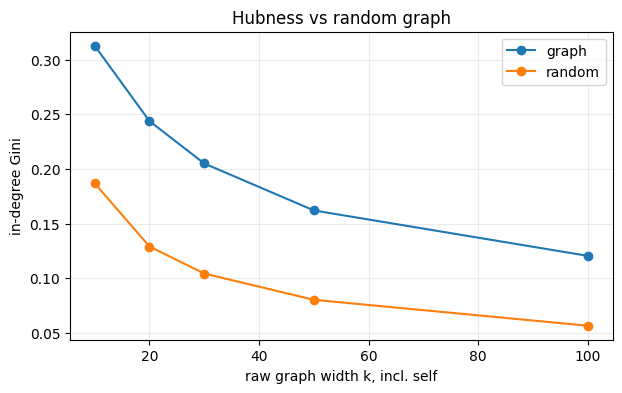

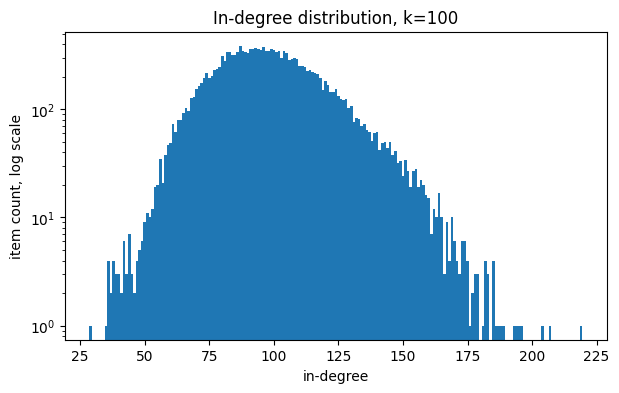

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(summary['k'], summary['indegree_gini'], marker='o', label='graph')
ax.plot(summary['k'], summary['random_indegree_gini_mean'], marker='o', label='random')
ax.set_xlabel('raw graph width k, incl. self')
ax.set_ylabel('in-degree Gini')
ax.set_title('Hubness vs random graph')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

k = int(summary['k'].max())
hist = indegree_hist[indegree_hist['k'] == k]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(hist['indegree'], hist['count'], width=1.0)
ax.set_yscale('log')
ax.set_xlabel('in-degree')
ax.set_ylabel('item count, log scale')
ax.set_title(f'In-degree distribution, k={k}')
plt.show()

- `In-degree`: how often an item appears in other items' neighbor lists.
- `Gini`: inequality of in-degree. `0` means perfectly uniform; higher values mean stronger hubs.
- The histogram shows how many items have each in-degree at the largest `k`, using a log y-axis.
- Main takeaway: hubs exist, but the effect is not extreme and it weakens as `k` increases.


## Popularity Bias

This checks whether graph hubs are simply popular training items. If yes, the graph might mostly be amplifying popularity rather than semantic structure.


Use the largest `k` slice for a direct popularity-vs-in-degree view. The scatter shows item-level behavior; the table groups items by training frequency.


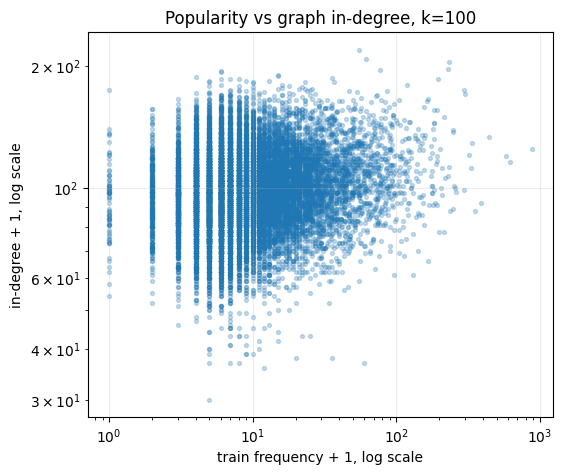

,k,bucket,bucket_min,bucket_max,n_items,train_frequency_mean,indegree_mean,indegree_median,indegree_p90,indegree_max
20,100,0-5,0,5.0,7210,3.784743,96.355340,94.0,123.0,194
21,100,6-10,6,10.0,5666,7.521179,98.522944,97.0,127.0,185
22,100,11-20,11,20.0,3140,14.486943,100.964650,99.0,129.0,189
23,100,21-50,21,50.0,1748,30.582952,104.134439,102.5,133.3,186
24,100,51+,51,NaN,593,94.924115,110.175379,108.0,142.8,219


In [7]:
k = int(summary['k'].max())
items = item_metrics[item_metrics['k'] == k].copy()

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(
    (items['train_frequency'] + 1),
    (items['indegree'] + 1),
    s=8,
    alpha=0.25,
)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('train frequency + 1, log scale')
ax.set_ylabel('in-degree + 1, log scale')
ax.set_title(f'Popularity vs graph in-degree, k={k}')
ax.grid(alpha=0.25)
plt.show()

popularity_buckets[popularity_buckets['k'] == k]

- `train_frequency`: how often an item appears in the training split.
- `in-degree`: how often the item is selected as a graph neighbor.
- A strong upward trend would mean popular items become graph hubs.
- The bucket table makes the same comparison after grouping items by popularity.
- Main takeaway: the relation is positive but weak, so popularity is probably not the main explanation for saturation.


## Dynamic B Analysis

These cells analyze actual graph decoding traces. They use the same graph-analysis session as the static section. If `dynamic/per_example.parquet` is not present yet, the cells print a short message and do nothing else.


In [8]:
dynamic_paths = {
    'per_example': DYNAMIC / 'per_example.parquet',
    'sample_traces': DYNAMIC / 'traces' / 'sample_traces.jsonl',
    'reachability': DYNAMIC / 'summaries' / 'dynamic_reachability_summary.csv',
    'redundancy': DYNAMIC / 'summaries' / 'dynamic_redundancy_summary.csv',
    'first_hit': DYNAMIC / 'summaries' / 'dynamic_first_hit_summary.csv',
    'saturation': DYNAMIC / 'summaries' / 'dynamic_saturation_summary.csv',
}

dynamic_available = dynamic_paths['per_example'].is_file()

if dynamic_available:
    dyn = pd.read_parquet(dynamic_paths['per_example'])
    reachability = pd.read_csv(dynamic_paths['reachability'])
    redundancy = pd.read_csv(dynamic_paths['redundancy'])
    first_hit = pd.read_csv(dynamic_paths['first_hit'])
    saturation = pd.read_csv(dynamic_paths['saturation'])
    print(f"Loaded dynamic outputs from {DYNAMIC}")
    display(saturation)
else:
    print(f"Dynamic outputs not found yet under {DYNAMIC}")
    print("Run/finish the dynamic Slurm job, then rerun this section.")


Loaded dynamic outputs from /gpfs/home6/scur1202/RPG/artifacts/rpg/graph_analysis/sports/20260615T153949Z_job23882755/dynamic


,n_edges,n_examples,reachable_rate,target_selected_rate,mean_visited_items,final_new_item_count_mean,final_prefix1_count_mean,final_prefix2_count_mean,final_prefix4_count_mean,ndcg@5,ndcg@10,recall@5,recall@10
0,10,106794,0.264865,0.038214,1700.089443,40.742757,232.787020,1392.932871,1584.513353,0.018156,0.022079,0.025938,0.038214
1,20,106794,0.403824,0.042662,3194.296047,35.389086,246.250819,2626.800157,3003.294932,0.020289,0.024701,0.028934,0.042662
2,30,106794,0.489850,0.043635,4573.137002,25.305083,250.221857,3747.693691,4318.368551,0.020573,0.025161,0.029402,0.043635
3,50,106794,0.608021,0.044085,6988.396867,12.107347,252.527782,5623.335084,6613.401755,0.020766,0.025401,0.029702,0.044085
4,100,106794,0.779791,0.044310,11223.992069,1.989110,254.111888,8643.234161,10602.731858,0.020842,0.025504,0.029833,0.044310


### B1. Target Reachability

This asks whether graph decoding ever visits the ground-truth item. The gap between `reachable_rate` and `target_selected_rate` separates graph-search failure from final ranking failure.


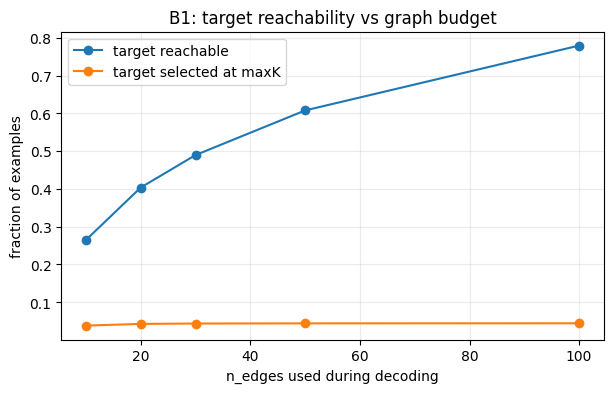

,n_edges,n_examples,reachable_rate,target_selected_rate,reachable_but_not_selected_rate,mean_visited_items
0,10,106794,0.264865,0.038214,0.226651,1700.089443
1,20,106794,0.403824,0.042662,0.361163,3194.296047
2,30,106794,0.489850,0.043635,0.446214,4573.137002
3,50,106794,0.608021,0.044085,0.563936,6988.396867
4,100,106794,0.779791,0.044310,0.735481,11223.992069


In [9]:
if dynamic_available:
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(reachability['n_edges'], reachability['reachable_rate'], marker='o', label='target reachable')
    ax.plot(reachability['n_edges'], reachability['target_selected_rate'], marker='o', label='target selected at maxK')
    ax.set_xlabel('n_edges used during decoding')
    ax.set_ylabel('fraction of examples')
    ax.set_title('B1: target reachability vs graph budget')
    ax.grid(alpha=0.25)
    ax.legend()
    plt.show()

    display(reachability)
else:
    print('B1 skipped: dynamic outputs not available yet.')


- `target reachable`: the true item appears somewhere in the cumulative visited set.
- `target selected at maxK`: the true item appears in the final generated list up to the evaluator maximum `topk`. -> basically the recall@k metric for the graph decoding (receall@10).







My opinion on the results:
- Increasing graph budget makes the target much easier to reach.
- The  final recommendation quality barely improves as the target becomes reachable, suggesting that the main bottleneck is ranking rather than search.

This suggests the bottleneck is not simply graph connectivity. The graph search can often touch the correct item, but the beam/scoring process does not keep or rank it high enough.


So for Figure 6 saturation, B1 supports this explanation:

> Adding more graph neighbors gives access to many more targets, but most of those targets are not useful in final ranking.


### B2. Redundancy of Visited Candidates

This checks whether extra propagation adds new areas or mostly repeats nearby/redundant candidates. Step `0` is the random initial beam set; later steps are graph expansions.


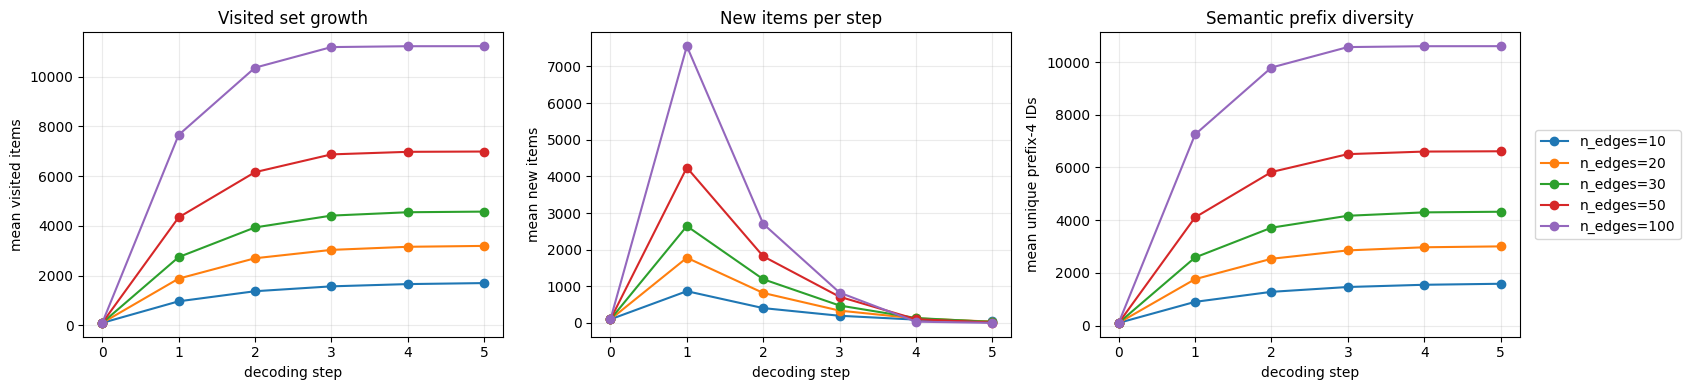

,n_edges,step,visited_count_mean,new_item_count_mean,unique_candidate_count_mean,duplicate_candidate_ratio_mean,novelty_ratio_mean,prefix1_count_mean,prefix2_count_mean,prefix4_count_mean
0,10,0,99.731970,99.731970,99.731970,0.002680,1.000000,80.926138,99.342707,99.648154
1,10,1,966.900294,867.168324,966.900294,0.033100,0.896844,216.153791,805.178203,897.979100
2,10,2,1372.355291,405.454997,623.464165,0.376536,0.649106,228.083937,1135.230828,1278.436017
3,10,3,1568.534375,196.179083,463.916522,0.536083,0.420155,231.118743,1289.604041,1461.597206
4,10,4,1659.346686,90.812312,389.292320,0.610708,0.230112,232.280081,1360.727251,1546.401549
5,10,5,1700.089443,40.742757,361.449950,0.638550,0.110005,232.787020,1392.932871,1584.513353
6,20,0,99.731970,99.731970,99.731970,0.002680,1.000000,80.926138,99.342707,99.648154
7,20,1,1879.150495,1779.418525,1879.150495,0.060425,0.946920,239.521556,1571.814091,1759.617198
8,20,2,2697.877708,818.727213,1132.756204,0.433622,0.720373,244.397906,2230.943330,2532.864393
9,20,3,3034.372380,336.494672,779.357838,0.610321,0.425693,245.653848,2497.866125,2851.287769


In [10]:
if dynamic_available:
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))

    for n_edges, group in redundancy.groupby('n_edges'):
        axes[0].plot(group['step'], group['visited_count_mean'], marker='o', label=f'n_edges={n_edges}')
        axes[1].plot(group['step'], group['new_item_count_mean'], marker='o', label=f'n_edges={n_edges}')
        axes[2].plot(group['step'], group['prefix4_count_mean'], marker='o', label=f'n_edges={n_edges}')

    axes[0].set_title('Visited set growth')
    axes[0].set_ylabel('mean visited items')
    axes[1].set_title('New items per step')
    axes[1].set_ylabel('mean new items')
    axes[2].set_title('Semantic prefix diversity')
    axes[2].set_ylabel('mean unique prefix-4 IDs')

    for axis in axes:
        axis.set_xlabel('decoding step')
        axis.grid(alpha=0.25)
    axes[2].legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    plt.tight_layout()
    plt.show()

    display(redundancy.head(12))
else:
    print('B2 skipped: dynamic outputs not available yet.')


- `visited set growth`: total unique items visited so far.
- `new items per step`: marginal new items added at each step.
- `prefix-4 diversity`: how many distinct first-4-token semantic-ID prefixes appear in the visited set.




  Increasing n_edges makes decoding visit many more items, but later propagation steps become highly redundant.

  Especially at large n_edges, most new discovery happens in steps 1-2. By steps 4-5, almost everything reachable from the current beams has already been seen.

  > So B2 supports the saturation story -> more graph width gives a big early expansion, but after that the search mostly cycles inside already-covered neighborhoods.

### B4. First-Hit / Path-Depth Analysis

This asks when the target is first reached during actual decoding. This is not a shortest-path computation: it includes RPG's real beam pruning.


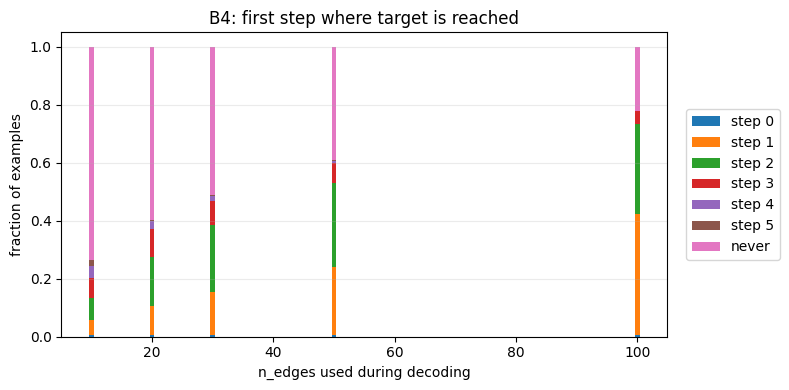

,n_edges,n_examples,first_reached_step_0_rate,first_reached_step_1_rate,first_reached_step_2_rate,first_reached_step_3_rate,first_reached_step_4_rate,first_reached_step_5_rate,never_reached_rate,mean_first_reached_step_reachable,median_first_reached_step_reachable
0,10,106794,0.00501,0.050518,0.076090,0.071558,0.041875,0.019814,0.735135,2.582231,3.0
1,20,106794,0.00501,0.101232,0.169785,0.093648,0.027717,0.006433,0.596176,2.141469,2.0
2,30,106794,0.00501,0.147930,0.233159,0.083329,0.017248,0.003174,0.510150,1.937530,2.0
3,50,106794,0.00501,0.234114,0.291861,0.066951,0.009008,0.001077,0.391979,1.743536,2.0
4,100,106794,0.00501,0.416540,0.310841,0.044937,0.002341,0.000122,0.220209,1.517082,1.0


In [11]:
if dynamic_available:
    step_cols = [col for col in first_hit.columns if col.startswith('first_reached_step_') and col.endswith('_rate')]
    plot_cols = step_cols + ['never_reached_rate']
    labels = [col.replace('first_reached_step_', 'step ').replace('_rate', '') for col in step_cols] + ['never']

    bottom = np.zeros(len(first_hit))
    fig, ax = plt.subplots(figsize=(8, 4))
    for col, label in zip(plot_cols, labels):
        values = first_hit[col].to_numpy()
        ax.bar(first_hit['n_edges'], values, bottom=bottom, label=label)
        bottom += values
    ax.set_xlabel('n_edges used during decoding')
    ax.set_ylabel('fraction of examples')
    ax.set_title('B4: first step where target is reached')
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5))
    ax.grid(axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

    display(first_hit)
else:
    print('B4 skipped: dynamic outputs not available yet.')


- Early first-hit mass means targets that are reachable are usually found quickly.
- A large `never` segment means the graph search never reaches many targets under this budget.
- If deeper steps rarely add target hits, increasing propagation depth is unlikely to help much.


when the graph width is larger, reachable targets are usually found very early. At n_edges=100, most reachable targets appear by step 1 or 2. Later propagation steps add little
  new target reachability. More graph budget makes more targets reachable,
  but most useful reachability happens early.
  After that, additional propagation mostly explores redundant or low-value candidates.

  > the search does not need many deep propagation steps to find most reachable targets, and when extra depth/width finds more targets, the ranking
  stage often still does not select them.

### B6. Saturation Curves

This puts recommendation quality and dynamic diagnostics on the same budget axis. The point is to see whether performance saturates together with reachability/diversity.


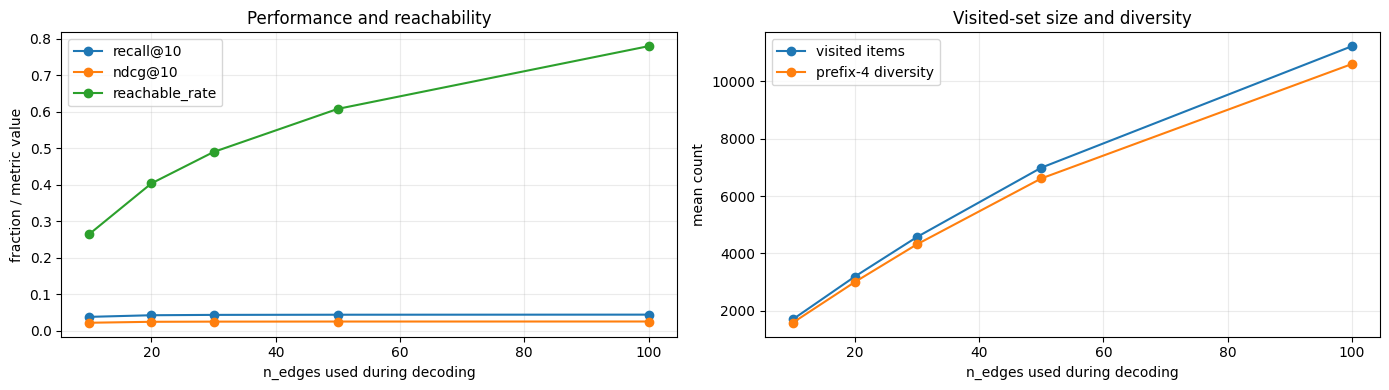

,n_edges,n_examples,reachable_rate,target_selected_rate,mean_visited_items,final_new_item_count_mean,final_prefix1_count_mean,final_prefix2_count_mean,final_prefix4_count_mean,ndcg@5,ndcg@10,recall@5,recall@10
0,10,106794,0.264865,0.038214,1700.089443,40.742757,232.787020,1392.932871,1584.513353,0.018156,0.022079,0.025938,0.038214
1,20,106794,0.403824,0.042662,3194.296047,35.389086,246.250819,2626.800157,3003.294932,0.020289,0.024701,0.028934,0.042662
2,30,106794,0.489850,0.043635,4573.137002,25.305083,250.221857,3747.693691,4318.368551,0.020573,0.025161,0.029402,0.043635
3,50,106794,0.608021,0.044085,6988.396867,12.107347,252.527782,5623.335084,6613.401755,0.020766,0.025401,0.029702,0.044085
4,100,106794,0.779791,0.044310,11223.992069,1.989110,254.111888,8643.234161,10602.731858,0.020842,0.025504,0.029833,0.044310


In [12]:
if dynamic_available:
    metric_candidates = [col for col in saturation.columns if col.startswith('recall@') or col.startswith('ndcg@')]
    preferred = [metric for metric in ['recall@10', 'ndcg@10'] if metric in metric_candidates]
    metrics_to_plot = preferred if preferred else metric_candidates[:2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    for metric in metrics_to_plot:
        axes[0].plot(saturation['n_edges'], saturation[metric], marker='o', label=metric)
    axes[0].plot(saturation['n_edges'], saturation['reachable_rate'], marker='o', label='reachable_rate')
    axes[0].set_title('Performance and reachability')
    axes[0].set_xlabel('n_edges used during decoding')
    axes[0].set_ylabel('fraction / metric value')
    axes[0].legend()
    axes[0].grid(alpha=0.25)

    axes[1].plot(saturation['n_edges'], saturation['mean_visited_items'], marker='o', label='visited items')
    axes[1].plot(saturation['n_edges'], saturation['final_prefix4_count_mean'], marker='o', label='prefix-4 diversity')
    axes[1].set_title('Visited-set size and diversity')
    axes[1].set_xlabel('n_edges used during decoding')
    axes[1].set_ylabel('mean count')
    axes[1].legend()
    axes[1].grid(alpha=0.25)

    plt.tight_layout()
    plt.show()

    display(saturation)
else:
    print('B6 skipped: dynamic outputs not available yet.')


 propagation_steps = 5 fixed

  Does the model PUT the correct item in the final top-10? That is recall@10 / target_selected.

=> only a little more.

  10 edges  -> recall@10 ~3.8%
  100 edges -> recall@10 ~4.4%

  > The correct item is often reached, but still not selected.

### Sample Trace Inspection

This is for qualitative debugging only. It loads a small deterministic sample of full traces if the dynamic job wrote them.


In [13]:
if dynamic_available and dynamic_paths['sample_traces'].is_file():
    with dynamic_paths['sample_traces'].open() as handle:
        sample_traces = [json.loads(line) for line in handle]
    print(f'Loaded {len(sample_traces)} sampled traces')
    if sample_traces:
        trace = sample_traces[0]
        print({
            'user_index': trace['user_index'],
            'eval_seed': trace['eval_seed'],
            'n_edges': trace['n_edges'],
            'target_item_id': trace['target_item_id'],
            'prediction_head': trace['predictions'][:10],
            'n_initial_items': len(trace['initial_items']),
            'n_final_visited_items': len(trace['final_visited_items']),
        })
else:
    print('Sample traces not available yet.')


Loaded 1920 sampled traces
{'user_index': 164, 'eval_seed': 2024, 'n_edges': 10, 'target_item_id': 1282, 'prediction_head': [1545, 1220, 5778, 1359, 1253, 1296, 1279, 7380, 1467, 1420], 'n_initial_items': 100, 'n_final_visited_items': 1905}


Use sampled traces only to understand individual cases. The quantitative claims should come from the aggregate B1/B2/B4/B6 tables above.
